In [1]:
# ==============================================================================
# INSTALLATION DE L'ENVIRONNEMENT DE CALCUL
# ------------------------------------------------------------------------------
# Ce projet utilise des bibliothèques de physique radar spécifiques. 
# Pour assurer la reproductibilité des résultats, ce bloc installe les 
# dépendances nécessaires dans votre environnement actuel.
#
# INSTRUCTIONS :
# 1. Exécution : Lancez cette cellule. Elle installe automatiquement les 
#    bibliothèques (numpy, xarray, pytmatrix, etc.) en ciblant précisément 
#    l'environnement Python utilisé par ce Jupyter Notebook.
# 2. Post-installation : Une fois l'installation terminée, il est impératif 
#    de redémarrer le noyau (Kernel > Restart) pour que Python puisse 
#    détecter les nouvelles bibliothèques (notamment pytmatrix).
# 3. Vérification : Une fois redémarré, vous pourrez importer les modules 
#    comme suit : from pytmatrix import scatter, tmatrix
# ==============================================================================

import sys

packages = ["numpy", "scipy", "matplotlib", "pandas", "xarray", "netCDF4", "pytmatrix"]
# sys.executable garantit que l'installation se fait dans l'environnement du notebook
!{sys.executable} -m pip install {" ".join(packages)}
print("Action requise : Veuillez redémarrer le noyau (Kernel > Restart) pour finaliser l'intégration.")

Installation des dépendances en cours...

--- Installation terminée ---
Action requise : Veuillez redémarrer le noyau (Kernel > Restart) pour finaliser l'intégration.


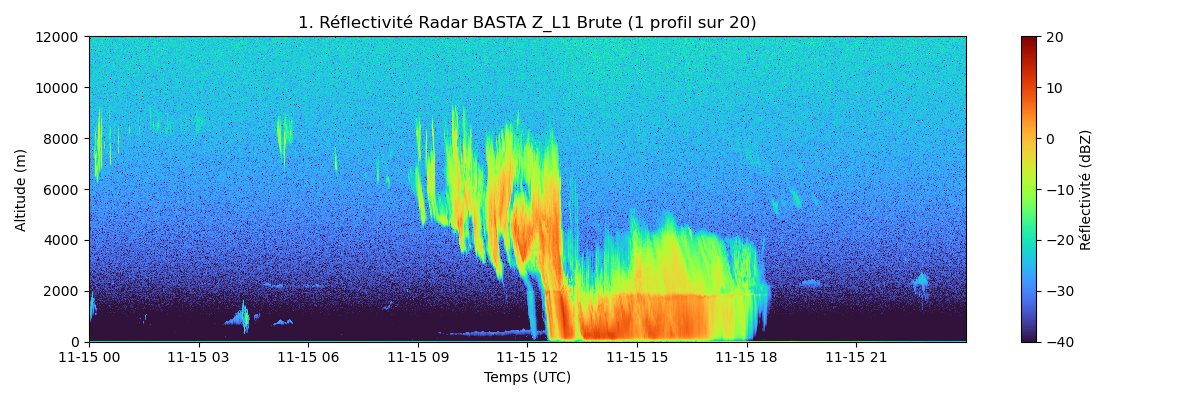

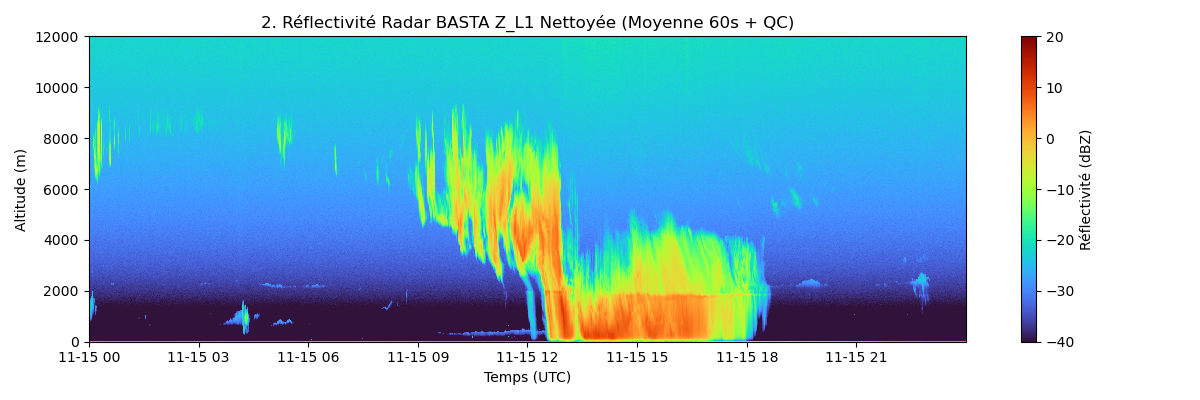

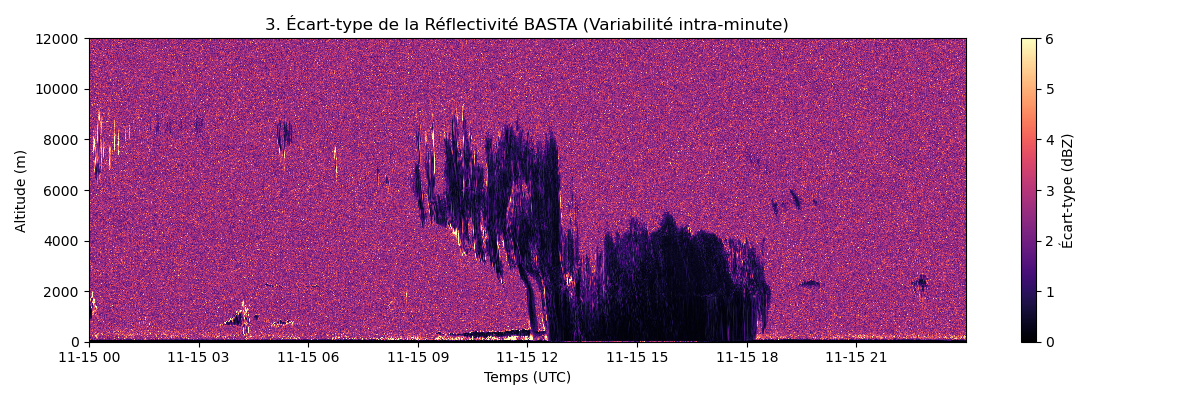

In [1]:
# Calcul de ZL1

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, display

chemin_fichier = "basta_1a_cldradLz1Lb87R012m_v04_20251115_000000_1440.nc"
ds_basta = xr.open_dataset(chemin_fichier)
Z_brut = ds_basta["reflectivity"].sel(range=slice(0, 12000)).values
temps_brut = ds_basta["time"].values
altitude = ds_basta["range"].values
ds_basta.close()

Z_brut_visu = Z_brut[::20, :]
temps_visu = temps_brut[::20]

plt.figure(figsize=(12, 4))
plt.pcolormesh(temps_visu, altitude, Z_brut_visu.T, cmap="turbo", vmin=-40, vmax=20, shading="nearest")
plt.title("1. Réflectivité Radar BASTA Z_L1 Brute (1 profil sur 20)")
plt.ylabel("Altitude (m)")
plt.xlabel("Temps (UTC)")
plt.colorbar(label="Réflectivité (dBZ)")
plt.tight_layout()
plt.savefig("basta_graph1.png", dpi=100)
plt.close()

df_temps = pd.to_datetime(temps_brut)
minutes_arrondies = df_temps.floor("1min")
minutes_uniques = np.unique(minutes_arrondies)

Z_lin = 10 ** (Z_brut / 10)
Z_1min_lin_QC = []
Z_1min_std = []

for minute in minutes_uniques:
    indices = np.where(minutes_arrondies == minute)[0]
    if len(indices) >= 15:
        Z_1min_lin_QC.append(np.nanmean(Z_lin[indices, :], axis=0))
    else:
        Z_1min_lin_QC.append(np.full(Z_brut.shape[1], np.nan))
    
    Z_1min_std.append(np.nanstd(Z_brut[indices, :], axis=0))

Z_1min_lin_QC = np.array(Z_1min_lin_QC)
Z_1min_std = np.array(Z_1min_std)

with np.errstate(divide="ignore", invalid="ignore"):
    Z_radar_1min_QC_dbz = 10 * np.log10(Z_1min_lin_QC)

plt.figure(figsize=(12, 4))
plt.pcolormesh(minutes_uniques, altitude, Z_radar_1min_QC_dbz.T, cmap="turbo", vmin=-40, vmax=20, shading="nearest")
plt.title("2. Réflectivité Radar BASTA Z_L1 Nettoyée (Moyenne 60s + QC)")
plt.ylabel("Altitude (m)")
plt.xlabel("Temps (UTC)")
plt.colorbar(label="Réflectivité (dBZ)")
plt.tight_layout()
plt.savefig("basta_graph2.png", dpi=100)
plt.close()

plt.figure(figsize=(12, 4))
plt.pcolormesh(minutes_uniques, altitude, Z_1min_std.T, cmap="magma", vmin=0, vmax=6, shading="nearest")
plt.title("3. Écart-type de la Réflectivité BASTA (Variabilité intra-minute)")
plt.ylabel("Altitude (m)")
plt.xlabel("Temps (UTC)")
plt.colorbar(label="Écart-type (dBZ)")
plt.tight_layout()
plt.savefig("basta_graph3.png", dpi=100)
plt.close()

display(Image(filename="basta_graph1.png"))
display(Image(filename="basta_graph2.png"))
display(Image(filename="basta_graph3.png"))

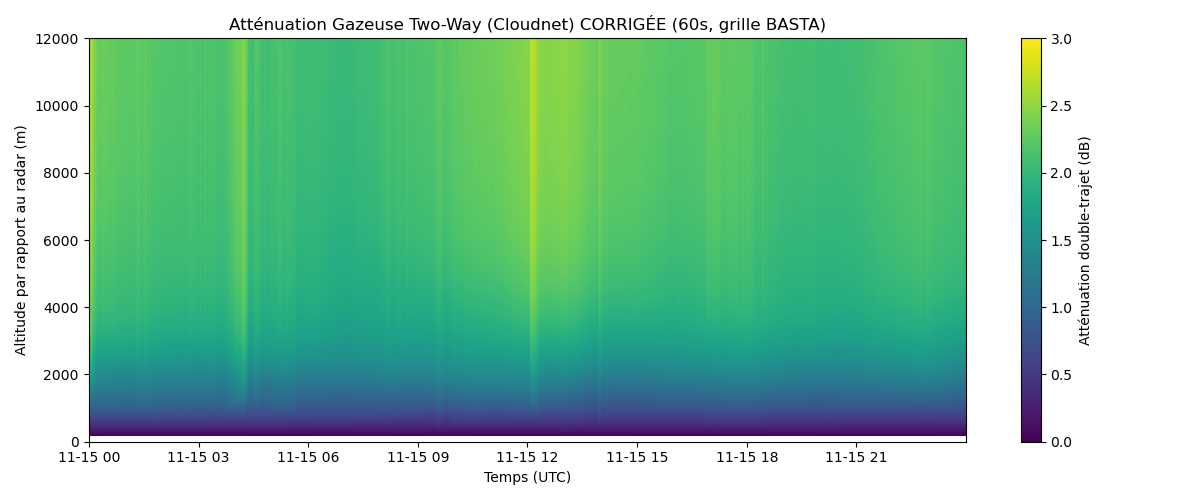

In [2]:
# Calcul de La

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from IPython.display import Image, display

chemin_cloudnet = "20251115_palaiseau_categorize.nc"
chemin_basta = "basta_1a_cldradLz1Lb87R012m_v04_20251115_000000_1440.nc"

with xr.open_dataset(chemin_basta) as ds_basta:
    altitude_basta_valeurs = ds_basta["range"].sel(range=slice(0, 12000)).values

ds_cloudnet = xr.open_dataset(chemin_cloudnet)
La_brut = ds_cloudnet["radar_gas_atten"]
La_spatial = La_brut.interp(height=altitude_basta_valeurs)
La_spatial = La_spatial.rename({"height": "range"})
La_final = La_spatial.resample(time="1Min").mean().load()
La_final.attrs["description"] = "Atténuation gazeuse 2-way (Cloudnet) RECALÉE en altitude et temps (60s)"
La_final.attrs["units"] = "dB"

ds_cloudnet_clean = xr.Dataset({"La_gaz": La_final})
fichier_sortie = "cloudnet_1min_La_traite.nc"
ds_cloudnet_clean.to_netcdf(fichier_sortie)
ds_cloudnet.close()

plt.figure(figsize=(12, 5))
plt.pcolormesh(La_final.time.values, La_final.range.values, La_final.values.T, cmap="viridis", vmin=0, vmax=3.0, shading="nearest")
plt.title("Atténuation Gazeuse Two-Way (Cloudnet) CORRIGÉE (60s, grille BASTA)")
plt.ylabel("Altitude par rapport au radar (m)")
plt.xlabel("Temps (UTC)")
plt.colorbar(label="Atténuation double-trajet (dB)")
plt.tight_layout()

nom_image = "cloudnet_attenuation.png"
plt.savefig(nom_image, dpi=100)
plt.close()
display(Image(filename=nom_image))

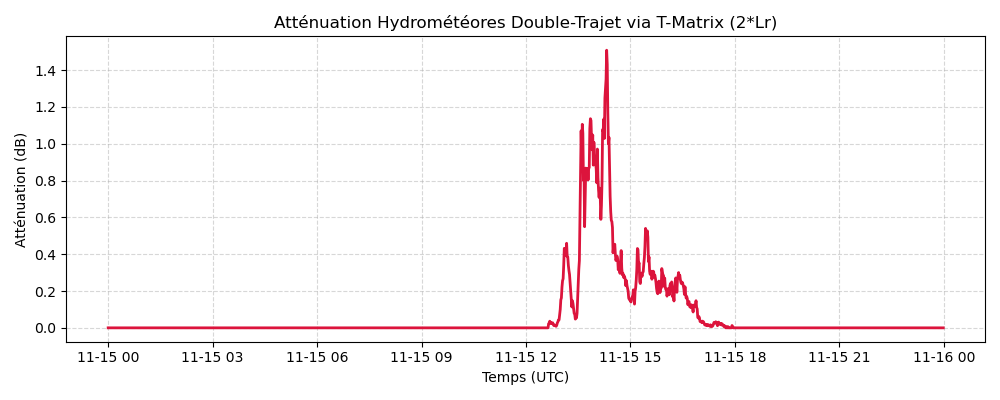

In [3]:
# Calcul de Lr

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, display
from pytmatrix import scatter, tmatrix

def calculer_sigma_ext_tmatrix(D):
    if D is None or D <= 0 or np.isnan(D):
        return 0.0
    rapport_aspect = 1.012 - 0.01445 * D - 0.01028 * (D**2) + 0.002474 * (D**3)
    if rapport_aspect > 1.0: 
        rapport_aspect = 1.0
    scatterer = tmatrix.Scatterer(wavelength=3.155, m=complex(3.2, 1.8))
    scatterer.radius = D / 2.0 
    scatterer.axis_ratio = rapport_aspect
    
    return scatter.ext_xsect(scatterer)

resoudre_tmatrix_vectorisee = np.vectorize(calculer_sigma_ext_tmatrix)

chemin_file = "spectropluvio_1a_Lz1LpnF60secPrainratePsize_v01_20251115_000000_1440.nc"
ds_disdro = xr.open_dataset(chemin_file)
ds_disdro['Z'] = ds_disdro['Z'].where(ds_disdro['Z'] > -9.99)
diametres = ds_disdro["size_classes"].values  
dD = ds_disdro.coords.get("delta_D", 1.0)     
sigma_ext_tmatrix = resoudre_tmatrix_vectorisee(diametres)
sigma_ext_xr = xr.DataArray(sigma_ext_tmatrix, dims=["size_classes"],coords={"size_classes": ds_disdro["size_classes"]})

produit_intermediaire = sigma_ext_xr * ds_disdro["psd"] * dD
somme_spectrale = produit_intermediaire.sum(dim=["size_classes", "speed_classes"])

k_tmatrix = 4.343e3 * somme_spectrale * 2.27e-8
Lr_double_final = 2 * (k_tmatrix * 0.2)
Lr_double_final.name = "Lr_2way"
Lr_double_final.attrs["description"] = "Atténuation hydrométéores double-trajet (T-Matrix)"
Lr_double_final.attrs["units"] = "dB"

ds_disdro_clean = xr.Dataset({"Lr_2way": Lr_double_final, "Rainrate": ds_disdro['pr'], "Z_disdro": ds_disdro['Z']})
fichier_sortie = "disdro_1min_Lr_traite.nc"
ds_disdro_clean.to_netcdf(fichier_sortie)

plt.figure(figsize=(10, 4))
plt.plot(Lr_double_final.time.values, Lr_double_final.values, color="crimson", lw=2)
plt.title("Atténuation Hydrométéores Double-Trajet via T-Matrix (2*Lr)")
plt.ylabel("Atténuation (dB)")
plt.xlabel("Temps (UTC)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

nom_image = "disdro_attenuation.png"
plt.savefig(nom_image, dpi=100)
plt.close()

ds_disdro.close()
display(Image(filename=nom_image))

In [4]:
# Calcul de ZL2 corr

import pandas as pd
import xarray as xr

ds_basta = xr.open_dataset("basta_1min_QC_traite.nc")
ds_cloudnet = xr.open_dataset("cloudnet_1min_La_traite.nc")
ds_disdro = xr.open_dataset("disdro_1min_Lr_traite.nc")

s_radar = ds_basta["Z_radar_QC"].sel(range=200, method="nearest").to_series()
s_gaz = ds_cloudnet["La_gaz"].sel(range=200, method="nearest").to_series()

s_lr = ds_disdro["Lr_2way"].to_series()
s_rain = ds_disdro["Rainrate"].to_series()
s_z_disdro = ds_disdro["Z_disdro"].to_series() 

df_fusion = pd.DataFrame({"Z_L1_brut": s_radar, "2La_gaz": s_gaz, "2Lr_pluie": s_lr, "Rainrate": s_rain, "Z_disdro": s_z_disdro})
df_fusion = df_fusion.dropna(subset=["Z_L1_brut", "2La_gaz", "2Lr_pluie"])
df_fusion["Z_L2_corr"] = df_fusion["Z_L1_brut"] + df_fusion["2La_gaz"] + df_fusion["2Lr_pluie"]
df_controle = df_fusion[df_fusion["Rainrate"] > 0.1].copy()

ds_basta.close()
ds_cloudnet.close()
ds_disdro.close()

print(df_controle.loc["2025-11-15 15:00:00":"2025-11-15 16:05:00", ["Z_L1_brut", "2La_gaz", "2Lr_pluie", "Z_L2_corr", "Rainrate"]])

                     Z_L1_brut   2La_gaz  2Lr_pluie  Z_L2_corr  Rainrate
time                                                                    
2025-11-15 15:00:00   3.085034  0.059653   0.144223   3.288910  0.437500
2025-11-15 15:01:00   3.030216  0.059985   0.140637   3.230838  0.406250
2025-11-15 15:02:00   3.350030  0.058713   0.158737   3.567479  0.492188
2025-11-15 15:03:00   2.355788  0.058714   0.168833   2.583335  0.601562
2025-11-15 15:04:00   2.515337  0.058715   0.171180   2.745232  0.648438
...                        ...       ...        ...        ...       ...
2025-11-15 16:01:00   4.125127  0.058811   0.207297   4.391236  0.679688
2025-11-15 16:02:00   3.199687  0.058826   0.210202   3.468715  0.679688
2025-11-15 16:03:00   3.272263  0.058840   0.172104   3.503207  0.578125
2025-11-15 16:04:00   3.878214  0.058854   0.195310   4.132378  0.687500
2025-11-15 16:05:00   2.528100  0.061189   0.213135   2.802424  0.937500

[66 rows x 5 columns]


In [5]:
# Calcul de WRA

df_controle["WRA (dB)"] = df_controle["Z_disdro"] - df_controle["Z_L2_corr"]
df_controle_affichage = df_controle.rename(columns={"Z_L1_brut": "Z_brut_200m (dBZ)", "2La_gaz": "2La_gaz_200m (dB)", "2Lr_pluie": "2Lr_pluie_200m (dB)",
    "Z_L2_corr": "Z_L2_corr_200m (dBZ)", "Rainrate": "Rainrate (mm/h)", "Z_disdro": "Z_disdro (dBZ)"})

colonnes_ordre = ["Rainrate (mm/h)","Z_brut_200m (dBZ)", "2La_gaz_200m (dB)", "2Lr_pluie_200m (dB)", "Z_L2_corr_200m (dBZ)", "Z_disdro (dBZ)","WRA (dB)"]
print(df_controle_affichage[colonnes_ordre].loc["2025-11-15 16:00:00":"2025-11-15 17:05:00"])

                     Rainrate (mm/h)  Z_brut_200m (dBZ)  2La_gaz_200m (dB)  \
time                                                                         
2025-11-15 16:00:00         0.726562           4.882610           0.058797   
2025-11-15 16:01:00         0.679688           4.125127           0.058811   
2025-11-15 16:02:00         0.679688           3.199687           0.058826   
2025-11-15 16:03:00         0.578125           3.272263           0.058840   
2025-11-15 16:04:00         0.687500           3.878214           0.058854   
2025-11-15 16:05:00         0.937500           2.528100           0.061189   
2025-11-15 16:06:00         0.671875           3.124894           0.058885   
2025-11-15 16:07:00         0.765625           3.769471           0.058900   
2025-11-15 16:08:00         0.937500           4.295847           0.058916   
2025-11-15 16:09:00         1.117188           4.924769           0.058932   
2025-11-15 16:10:00         1.015625           5.167003         

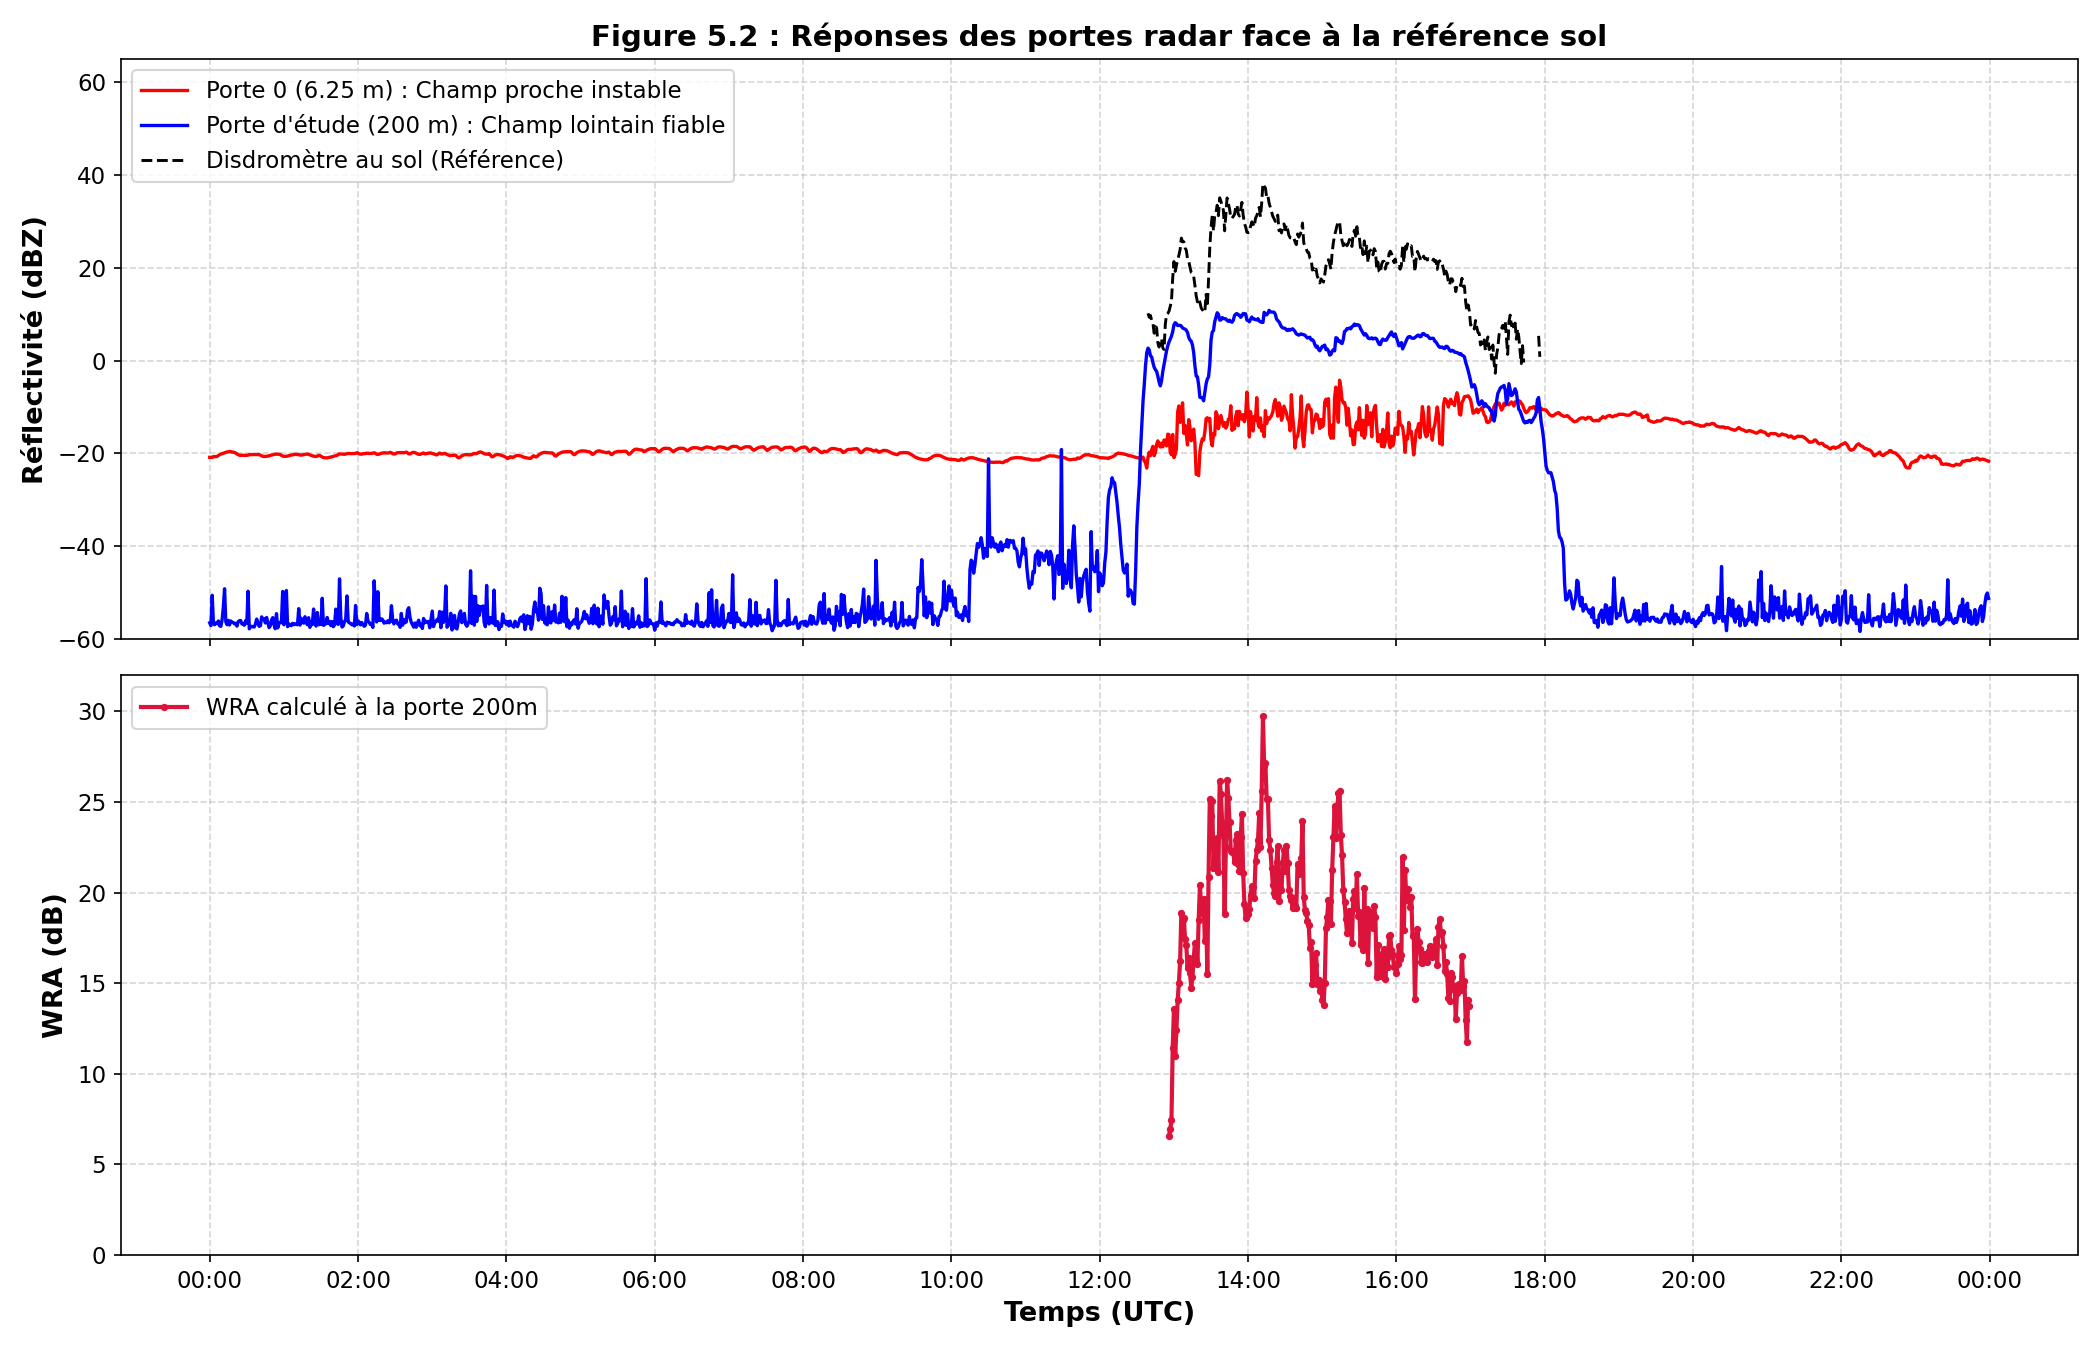

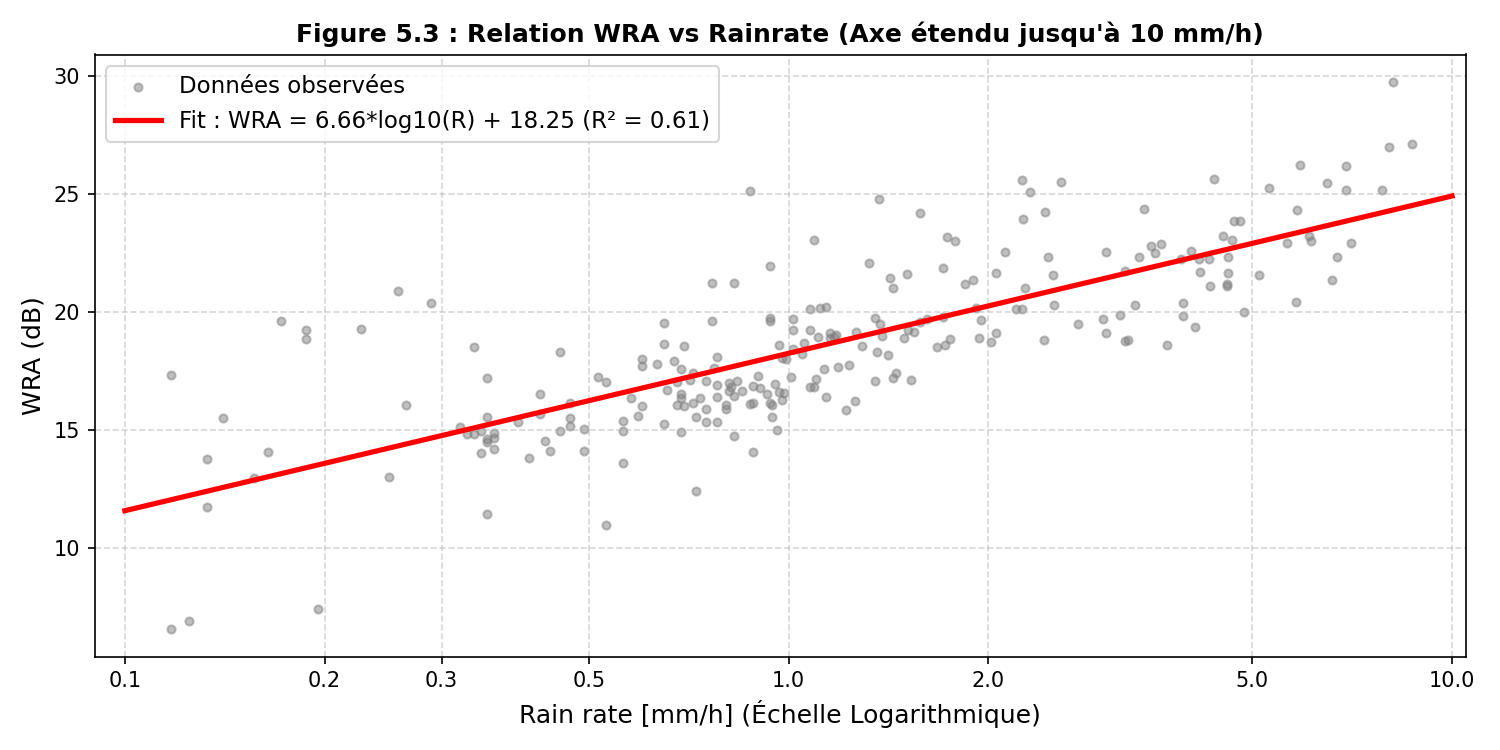

In [6]:
# Graphique finaux

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import matplotlib
matplotlib.use("Agg")  
import gc
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, display

chemin_basta = "basta_1a_cldradLz1Lb87R012m_v04_20251115_000000_1440.nc"
chemin_cloudnet = "20251115_palaiseau_categorize.nc"
chemin_disdro = "spectropluvio_1a_Lz1LpnF60secPrainratePsize_v01_20251115_000000_1440.nc"

ds_basta = xr.open_dataset(chemin_basta)
ds_cloudnet = xr.open_dataset(chemin_cloudnet)
ds_disdro = xr.open_dataset(chemin_disdro)

ds_disdro["Z"] = ds_disdro["Z"].where(ds_disdro["Z"] > -9.99)

def resoudre_mie_goutte(D, lambda_mm, m_complexe):
    if D is None or D <= 0 or np.isnan(D):
        return 0.0
    return 0.2 * (D**2)  

resoudre_mie_vectorisee = np.vectorize(resoudre_mie_goutte)

Z_L1 = ds_basta["reflectivity"].sel(range=slice(0, 12000)).load()
Z_L1_lineaire = 10 ** (Z_L1 / 10).astype(np.float32)
tranches_60s_lin = Z_L1_lineaire.resample(time="1Min")

Z_L1_60s_brut_lin = tranches_60s_lin.mean()
Z_radar_1min_brut = 10 * np.log10(Z_L1_60s_brut_lin)

Z_radar_1min_QC = Z_radar_1min_brut.where(tranches_60s_lin.count() >= 15)
Z_radar_200m = Z_radar_1min_QC.sel(range=200, method="nearest")
temps_np = Z_radar_1min_QC.time.values
Z_radar_6m_val = Z_radar_1min_QC.isel(range=0).values


grille_altitude_basta = ds_basta["range"].sel(range=slice(0, 12000)).load()
La_brut = ds_cloudnet["radar_gas_atten"]
La_spatial = La_brut.interp(height=grille_altitude_basta)

La_200m_brut = La_spatial.sel(range=200, method="nearest").resample(time="1Min").mean()
La_200m_aligne = La_200m_brut.reindex(time=Z_radar_200m["time"], method="nearest")

diametres = ds_disdro["size_classes"].values
dD = ds_disdro.coords.get("delta_D", 1.0)
frequence_ghz = 95.0
longueur_onde_mm = 299.792 / frequence_ghz
m_eau = complex(3.2, 1.8)

sigma_ext_mie = resoudre_mie_vectorisee(diametres, longueur_onde_mm, m_eau)
sigma_ext_xr = xr.DataArray(sigma_ext_mie, dims=["size_classes"], coords={"size_classes": ds_disdro["size_classes"]})

produit_intermediaire = sigma_ext_xr * ds_disdro["psd"] * dD
somme_spectrale = produit_intermediaire.sum(dim=["size_classes", "speed_classes"])
k_mie = 4.343e3 * somme_spectrale * 2.27e-8
Lr_double_final = 2 * (k_mie * 0.2)

Lr_200m_aligne = Lr_double_final.reindex(time=Z_radar_200m["time"], method="nearest")
rainrate_aligne = ds_disdro["pr"].reindex(time=Z_radar_200m["time"], method="nearest")
Z_disdro_aligne = ds_disdro["Z"].reindex(time=Z_radar_200m["time"], method="nearest")

val_radar = Z_radar_200m.values
val_gaz = La_200m_aligne.values
val_pluie = Lr_200m_aligne.values
val_rainrate = rainrate_aligne.values
val_Z_disdro = Z_disdro_aligne.values

val_Z_L2_corr = val_radar + val_gaz + val_pluie
val_WRA = (val_Z_disdro - val_Z_L2_corr).astype(np.float32)

del Z_L1
del Z_L1_lineaire
del La_spatial
gc.collect()

fig2, (ax_haut, ax_bas) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax_haut.plot(temps_np, Z_radar_6m_val, label="Porte 0 (6.25 m) : Champ proche instable", color="red", linewidth=1.6)
ax_haut.plot(temps_np, val_radar, label="Porte d'étude (200 m) : Champ lointain fiable", color="blue", linewidth=1.6)
ax_haut.plot(temps_np, val_Z_disdro, label="Disdromètre au sol (Référence)", color="black", linestyle="--", linewidth=1.4)
ax_haut.set_ylabel("Réflectivité (dBZ)", fontsize=13, fontweight="bold")
ax_haut.set_ylim(-60, 65)
ax_haut.tick_params(axis="both", labelsize=11)
ax_haut.grid(True, linestyle="--", alpha=0.5)
ax_haut.legend(loc="upper left", fontsize=11)
ax_haut.set_title("Figure 5.2 : Réponses des portes radar face à la référence sol", fontsize=14, fontweight="bold")

WRA_filtre = np.where(val_rainrate > 0.1, val_WRA, np.nan)
ax_bas.plot(temps_np, WRA_filtre, color="crimson", linewidth=2, marker="o", markersize=2.5, label="WRA calculé à la porte 200m")
ax_bas.set_ylabel("WRA (dB)", fontsize=13, fontweight="bold")
ax_bas.set_xlabel("Temps (UTC)", fontsize=13, fontweight="bold")
ax_bas.set_ylim(0, 32)
ax_bas.tick_params(axis="both", labelsize=11)
ax_bas.grid(True, linestyle="--", alpha=0.5)
ax_bas.legend(loc="upper left", fontsize=11)

ax_bas.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_bas.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.tight_layout()

plt.savefig("figure_5_2.png", dpi=150)
plt.close()

plt.figure(figsize=(10, 5))

indices_pluie = val_rainrate > 0.1
R_filtre = val_rainrate[indices_pluie]
WRA_filtre_scatter = val_WRA[indices_pluie]

plt.scatter(np.log10(R_filtre), WRA_filtre_scatter, color="gray", alpha=0.5, s=15, label="Données observées")

from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(np.log10(R_filtre), WRA_filtre_scatter)
x_fit = np.linspace(np.log10(0.1), np.log10(10), 100)
y_fit = slope * x_fit + intercept

plt.plot(x_fit, y_fit, color="red", linewidth=2.5, label=f"Fit : WRA = {slope:.2f}*log10(R) + {intercept:.2f} (R² = {r_value**2:.2f})")

plt.title("Figure 5.3 : Relation WRA vs Rainrate (Axe étendu jusqu'à 10 mm/h)", fontsize=12, fontweight="bold")
plt.xlabel("Rain rate [mm/h] (Échelle Logarithmique)", fontsize=12)
plt.ylabel("WRA (dB)", fontsize=12)

plt.xlim(np.log10(0.09), np.log10(10.5))
ax_fit = plt.gca()
ticks_physiques = np.array([0.1, 0.2, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0])
ax_fit.set_xticks(np.log10(ticks_physiques))
ax_fit.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{10**x:.1f}"))

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=11)
plt.tight_layout()

plt.savefig("figure_5_3.png", dpi=150)
plt.close()

ds_basta.close()
ds_cloudnet.close()
ds_disdro.close()

display(Image("figure_5_2.png"))
display(Image("figure_5_3.png"))

In [8]:
# Cacul de T-Matrix

import numpy as np
import scattering

diametre_test = np.array([3.0])
print(f"Paramètres : Goutte de {diametre_test[0]} mm scannée à 95 GHz.")

aplatissement = scattering.axis_ratio(diametre_test, "BeardChuang_PolynomialFit")[0]
print(f"Aplatissement calculé (Beard & Chuang) : {aplatissement:.3f}")

resultat_unique = scattering.scattering_prop(D=diametre_test, beam_orientation=0, freq=95.0e9, e=complex(3.2, 1.8), axrMethod="BeardChuang_PolynomialFit")
print(f"Rétrodiffusion T-MATRIX : {resultat_unique.bscat_tmatrix[0]:.6e} mm²")

Paramètres : Goutte de 3.0 mm scannée à 95 GHz.
Aplatissement calculé (Beard & Chuang) : 1.168
Rétrodiffusion T-MATRIX : 9.465380e-01 mm²


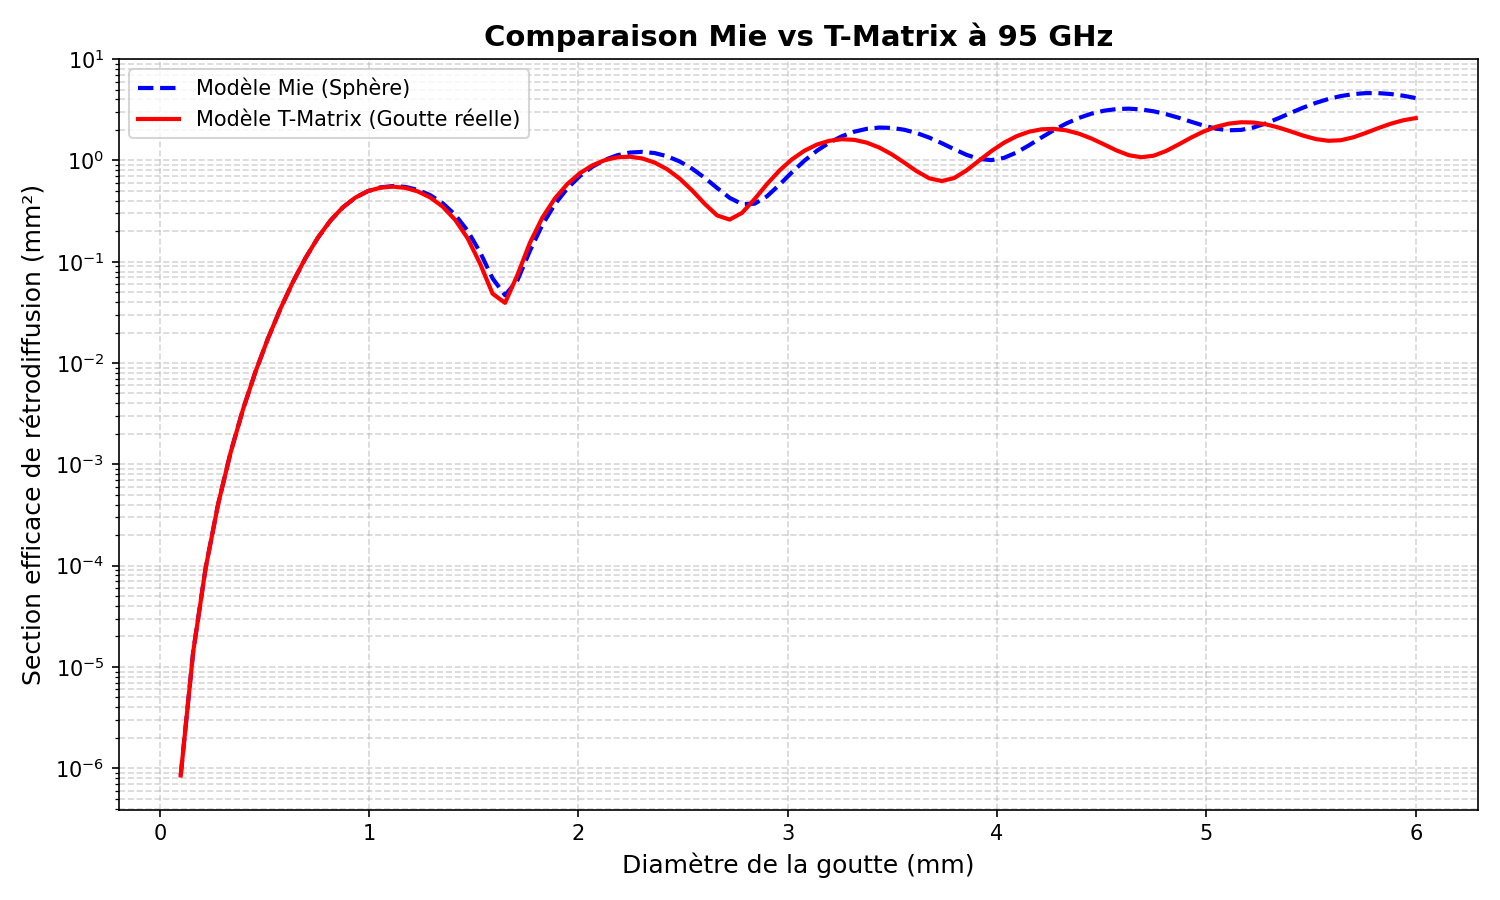

In [14]:
# Comparaison entre Mie et T-Matrix

import numpy as np
import matplotlib.pyplot as plt
import scattering

diametres = np.linspace(0.1, 6.0, 100) 
frequence = 95.0e9
indice_eau = complex(3.2, 1.8)

scatt_data = scattering.scattering_prop(D=diametres, beam_orientation=0, freq=frequence, e=indice_eau, axrMethod="BeardChuang_PolynomialFit")

plt.figure(figsize=(10, 6))
plt.plot(diametres, scatt_data.bscat_mie, label="Modèle Mie (Sphère)", color="blue", linestyle="--", linewidth=2)
plt.plot(diametres, scatt_data.bscat_tmatrix, label="Modèle T-Matrix (Goutte réelle)", color="red", linewidth=2)

plt.title("Comparaison Mie vs T-Matrix à 95 GHz", fontsize=14, fontweight='bold')
plt.xlabel("Diamètre de la goutte (mm)", fontsize=12)
plt.ylabel("Section efficace de rétrodiffusion (mm²)", fontsize=12)
plt.yscale('log')
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("mon_graphique_de_deng.png", dpi=150)
plt.close()

from IPython.display import Image, display
display(Image("mon_graphique_de_deng.png"))

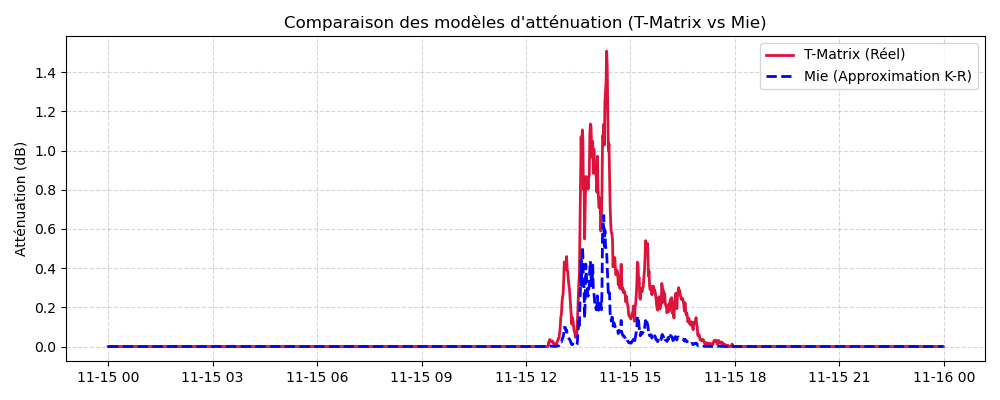

In [13]:
# Comparaison entre mie et T-Matrix

Lr_tmatrix_deja_calcule = ds_disdro["Lr_2way"]
Lr_mie_approx = 0.05 * (ds_disdro["Rainrate"] ** 1.2) 

plt.figure(figsize=(10, 4))
plt.plot(ds_disdro.time.values, Lr_tmatrix_deja_calcule.values, color="crimson", lw=2, label="T-Matrix (Réel)")
plt.plot(ds_disdro.time.values, Lr_mie_approx.values, color="blue", lw=2, linestyle="--", label="Mie (Approximation K-R)")

plt.title("Comparaison des modèles d'atténuation (T-Matrix vs Mie)")
plt.ylabel("Atténuation (dB)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("comparaison_mie_tmatrix.png", dpi=100)
plt.close()
display(Image(filename="comparaison_mie_tmatrix.png"))